In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# from the repository root or from the Notebooks folder.
ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "house_prices_cleaned_featured.csv"
REPORTS_PATH = ROOT / "reports"

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Processed dataset:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the processed dataset at {DATA_PATH}. "
    )

Repository root: C:\Users\Hp\Desktop\K-LAB
Processed dataset: C:\Users\Hp\Desktop\K-LAB\data\processed\house_prices_cleaned_featured.csv


In [2]:
# Task 1: Load and Explore the Processed Dataset

# This notebook reuses the same cleaned dataset as Assignments 3 and 4, so this section only checks that it loaded correctly.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (4551, 24)

Columns:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country', 'city_listing_count', 'city_avg_price', 'city_median_price', 'city_avg_sqft_living', 'price_vs_city_avg', 'price_zscore']


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,street,city,statezip,country,city_listing_count,city_avg_price,city_median_price,city_avg_sqft_living,price_vs_city_avg,price_zscore
0,2014-05-02,313000.0,3,1.50,1340,7912,1.5,0,0,3,...,18810 Densmore Ave N,Shoreline,WA 98133,USA,123,420392.364047,360000.0,1774.837398,-1.073924e+05,-0.434332
1,2014-05-02,2384000.0,5,2.50,3650,9050,2.0,0,4,5,...,709 W Blaine St,Seattle,WA 98119,USA,1561,584294.898165,490000.0,1826.242793,1.799705e+06,3.238514
2,2014-05-02,342000.0,3,2.00,1930,11947,1.0,0,0,4,...,26206-26214 143rd Ave SE,Kent,WA 98042,USA,184,441880.990543,283600.0,1980.190217,-9.988099e+04,-0.382902
3,2014-05-02,420000.0,3,2.25,2000,8030,1.0,0,0,4,...,857 170th Pl NE,Bellevue,WA 98008,USA,281,862255.052017,725000.0,2673.113879,-4.422551e+05,-0.244571
4,2014-05-02,550000.0,4,2.50,1940,10500,1.0,0,0,4,...,9105 170th Ave NE,Redmond,WA 98052,USA,235,667649.534781,638000.0,2491.761702,-1.176495e+05,-0.014021


In [4]:
# Task 2: Create the Premium Classification Target

# A house is labelled premium when its sale price is at least $1,000,000. The target is derived from price, so price itself is excluded from the model features to avoid target leakage.

In [5]:
PREMIUM_THRESHOLD = 1_000_000

df["premium"] = (
    df["price"] >= PREMIUM_THRESHOLD
).astype(int)

print("Premium threshold:", f"${PREMIUM_THRESHOLD:,}")

df[["price", "premium"]].head()

Premium threshold: $1,000,000


,price,premium
0,313000.0,0
1,2384000.0,1
2,342000.0,0
3,420000.0,0
4,550000.0,0


In [6]:
# Task 3: Check Class Distribution

# The premium class is rare, so this is checked before training so the results can be read with that imbalance in mind.

In [7]:
class_counts = df["premium"].value_counts().sort_index()
class_percentages = (
    df["premium"].value_counts(normalize=True).sort_index() * 100
)

print("CLASS DISTRIBUTION")
print("------------------")
print("Regular houses:", class_counts.get(0, 0))
print("Premium houses:", class_counts.get(1, 0))

print(f"\nRegular: {class_percentages.get(0, 0):.1f}%")
print(f"Premium: {class_percentages.get(1, 0):.1f}%")

CLASS DISTRIBUTION
------------------
Regular houses: 4207
Premium houses: 344

Regular: 92.4%
Premium: 7.6%


In [8]:
# Task 4: Select Features and Target

# Features:
# - sqft_living
# - yr_built
#
# Target:
# - premium
#
# Only two features are used on purpose. It keeps the feature space two-dimensional, so every classifier below can be visualized directly and its reasoning can be inspected feature by feature.

In [9]:
features = ["sqft_living", "yr_built"]
target = "premium"

required_columns = features + [target]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

model_df = df[required_columns].copy()

print("Selected columns:")
print(model_df.head())

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nSummary statistics:")
model_df.describe()

Selected columns:
   sqft_living  yr_built  premium
0         1340      1955        0
1         3650      1921        1
2         1930      1966        0
3         2000      1963        0
4         1940      1976        0

Missing values:
sqft_living    0
yr_built       0
premium        0
dtype: int64

Summary statistics:


,sqft_living,yr_built,premium
count,4551.000000,4551.000000,4551.000000
mean,2132.372226,1970.795649,0.075588
std,955.949708,29.760073,0.264366
min,370.000000,1900.000000,0.000000
25%,1460.000000,1951.000000,0.000000
50%,1970.000000,1976.000000,0.000000
75%,2610.000000,1997.000000,0.000000
max,13540.000000,2014.000000,1.000000


In [10]:
# Task 5: Prepare Training and Testing Data

# The data is split into:
#
# - 80% training data, used to teach the models.
# - 20% testing data, used to evaluate predictions on unseen houses.
#
# The split is stratified on the target so both sets keep the same premium/regular ratio as the full dataset. Every classifier below is trained and evaluated on exactly this same split.

In [11]:
# Remove any unexpected missing values only from the columns used here.
model_df = model_df.dropna().copy()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(f"\nPremium % in full dataset: {y.mean() * 100:.2f}%")
print(f"Premium % in training data: {y_train.mean() * 100:.2f}%")
print(f"Premium % in testing data: {y_test.mean() * 100:.2f}%")

Training rows: 3640
Testing rows: 911

Premium % in full dataset: 7.56%
Premium % in training data: 7.55%
Premium % in testing data: 7.57%


In [12]:
# Task 6: Choose an Example House to Explain

# One house from the test set is used throughout the rest of this notebook so every algorithm's reasoning can be compared side by side on exactly the same input.

In [13]:
EXAMPLE_INDEX = 0

example_df = X_test.iloc[[EXAMPLE_INDEX]]
example_true_label = y_test.iloc[EXAMPLE_INDEX]

print("EXAMPLE HOUSE")
print("-------------")
print(example_df)

print(f"\nTrue label: {'Premium' if example_true_label == 1 else 'Regular'}")

EXAMPLE HOUSE
-------------
      sqft_living  yr_built
1807         1220      1921

True label: Regular


In [14]:
# Task 7: Decision Tree Classifier

# A Decision Tree predicts by asking a sequence of yes/no questions about the features. Each internal node splits the data on one feature and threshold, and the leaf that a house ends up in gives the prediction. It is used first here because its reasoning can be read directly, one split at a time.

In [15]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(X_test)
tree_probabilities = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [16]:
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions, zero_division=0)
tree_recall = recall_score(y_test, tree_predictions, zero_division=0)
tree_f1 = f1_score(y_test, tree_predictions, zero_division=0)
tree_auc = roc_auc_score(y_test, tree_probabilities)

print("DECISION TREE RESULTS")
print("----------------------")
print(f"Accuracy:  {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall:    {tree_recall:.3f}")
print(f"F1 Score:  {tree_f1:.3f}")
print(f"ROC-AUC:   {tree_auc:.3f}")

DECISION TREE RESULTS
----------------------
Accuracy:  0.791
Precision: 0.257
Recall:    0.928
F1 Score:  0.403
ROC-AUC:   0.918


In [17]:
print("DECISION TREE RULES (max depth 4)")
print("-----------------------------------")
print(
    export_text(
        tree_model,
        feature_names=features
    )
)

DECISION TREE RULES (max depth 4)
-----------------------------------
|--- sqft_living <= 2725.00
|   |--- sqft_living <= 2087.50
|   |   |--- yr_built <= 1903.50
|   |   |   |--- sqft_living <= 1455.00
|   |   |   |   |--- class: 0
|   |   |   |--- sqft_living >  1455.00
|   |   |   |   |--- class: 1
|   |   |--- yr_built >  1903.50
|   |   |   |--- yr_built <= 1937.50
|   |   |   |   |--- class: 0
|   |   |   |--- yr_built >  1937.50
|   |   |   |   |--- class: 0
|   |--- sqft_living >  2087.50
|   |   |--- yr_built <= 1960.50
|   |   |   |--- sqft_living <= 2685.00
|   |   |   |   |--- class: 1
|   |   |   |--- sqft_living >  2685.00
|   |   |   |   |--- class: 0
|   |   |--- yr_built >  1960.50
|   |   |   |--- sqft_living <= 2545.00
|   |   |   |   |--- class: 0
|   |   |   |--- sqft_living >  2545.00
|   |   |   |   |--- class: 0
|--- sqft_living >  2725.00
|   |--- sqft_living <= 3756.50
|   |   |--- yr_built <= 1988.50
|   |   |   |--- yr_built <= 1939.50
|   |   |   |   |--- c

In [18]:
node_indicator = tree_model.decision_path(example_df)
leaf_id = tree_model.apply(example_df)

sample_id = 0
node_index = node_indicator.indices[
    node_indicator.indptr[sample_id]: node_indicator.indptr[sample_id + 1]
]

print("HOW THE DECISION TREE REACHED ITS PREDICTION")
print("-----------------------------------------------")

for node_id in node_index:
    if leaf_id[sample_id] == node_id:
        leaf_class = tree_model.classes_[
            tree_model.tree_.value[node_id].argmax()
        ]
        leaf_label = "Premium" if leaf_class == 1 else "Regular"
        print(f"Leaf node {node_id}: predict {leaf_label}")
        continue

    feature_index = tree_model.tree_.feature[node_id]
    threshold = tree_model.tree_.threshold[node_id]
    feature_name = features[feature_index]
    feature_value = example_df.iloc[sample_id, feature_index]
    answer_yes = feature_value <= threshold

    print(
        f"Node {node_id}: is {feature_name} = {feature_value} <= {threshold:.2f}? "
        f"{'Yes' if answer_yes else 'No'}"
    )

print(f"\nModel's predicted probability for Premium: {tree_probabilities[EXAMPLE_INDEX]:.3f}")

HOW THE DECISION TREE REACHED ITS PREDICTION
-----------------------------------------------
Node 0: is sqft_living = 1220 <= 2725.00? Yes
Node 1: is sqft_living = 1220 <= 2087.50? Yes
Node 2: is yr_built = 1921 <= 1903.50? No
Node 6: is yr_built = 1921 <= 1937.50? Yes
Leaf node 7: predict Regular

Model's predicted probability for Premium: 0.131


In [19]:
# Task 8: K-Nearest Neighbors Classifier

# KNN predicts by finding the most similar training houses, measured by Euclidean distance after scaling the features, and combining their labels. Closer neighbors are weighted more heavily than farther ones.

In [20]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=25,
        weights="distance"
    ))
])

knn_model.fit(
    X_train,
    y_train
)

knn_predictions = knn_model.predict(X_test)
knn_probabilities = knn_model.predict_proba(X_test)[:, 1]

print("K-Nearest Neighbors trained successfully.")

K-Nearest Neighbors trained successfully.


In [21]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions, zero_division=0)
knn_recall = recall_score(y_test, knn_predictions, zero_division=0)
knn_f1 = f1_score(y_test, knn_predictions, zero_division=0)
knn_auc = roc_auc_score(y_test, knn_probabilities)

print("K-NEAREST NEIGHBORS RESULTS")
print("-----------------------------")
print(f"Accuracy:  {knn_accuracy:.3f}")
print(f"Precision: {knn_precision:.3f}")
print(f"Recall:    {knn_recall:.3f}")
print(f"F1 Score:  {knn_f1:.3f}")
print(f"ROC-AUC:   {knn_auc:.3f}")

K-NEAREST NEIGHBORS RESULTS
-----------------------------
Accuracy:  0.930
Precision: 0.553
Recall:    0.377
F1 Score:  0.448
ROC-AUC:   0.882


In [22]:
knn_scaler = knn_model.named_steps["scaler"]
knn_estimator = knn_model.named_steps["model"]

example_scaled = knn_scaler.transform(example_df)
distances, neighbor_positions = knn_estimator.kneighbors(example_scaled)

neighbor_labels = y_train.iloc[neighbor_positions[0]].to_numpy()
neighbor_weights = 1 / np.where(distances[0] == 0, 1e-12, distances[0])

weighted_vote = (
    (neighbor_weights * (neighbor_labels == 1)).sum()
    / neighbor_weights.sum()
)

print("HOW KNN REACHED ITS PREDICTION")
print("---------------------------------")
print(f"Looking at the {knn_estimator.n_neighbors} closest training houses:")
print(f"  Premium neighbors: {(neighbor_labels == 1).sum()}")
print(f"  Regular neighbors: {(neighbor_labels == 0).sum()}")

print(f"\nDistance-weighted vote for Premium: {weighted_vote:.3f}")
print(f"Model's predicted probability for Premium: {knn_probabilities[EXAMPLE_INDEX]:.3f}")

HOW KNN REACHED ITS PREDICTION
---------------------------------
Looking at the 25 closest training houses:
  Premium neighbors: 0
  Regular neighbors: 25

Distance-weighted vote for Premium: 0.000
Model's predicted probability for Premium: 0.000


In [23]:
# Task 9: Naive Bayes Classifier

# Gaussian Naive Bayes assumes each feature is normally distributed within each class and treats the features as independent of each other. It multiplies together how likely each feature value is under each class, then picks the class with the higher combined score.

In [24]:
nb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

nb_model.fit(
    X_train,
    y_train
)

nb_predictions = nb_model.predict(X_test)
nb_probabilities = nb_model.predict_proba(X_test)[:, 1]

print("Naive Bayes trained successfully.")

Naive Bayes trained successfully.


In [25]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, zero_division=0)
nb_recall = recall_score(y_test, nb_predictions, zero_division=0)
nb_f1 = f1_score(y_test, nb_predictions, zero_division=0)
nb_auc = roc_auc_score(y_test, nb_probabilities)

print("NAIVE BAYES RESULTS")
print("----------------------")
print(f"Accuracy:  {nb_accuracy:.3f}")
print(f"Precision: {nb_precision:.3f}")
print(f"Recall:    {nb_recall:.3f}")
print(f"F1 Score:  {nb_f1:.3f}")
print(f"ROC-AUC:   {nb_auc:.3f}")

NAIVE BAYES RESULTS
----------------------
Accuracy:  0.937
Precision: 0.636
Recall:    0.406
F1 Score:  0.496
ROC-AUC:   0.935


In [26]:
nb_scaler = nb_model.named_steps["scaler"]
nb_estimator = nb_model.named_steps["model"]

example_scaled = nb_scaler.transform(example_df)[0]

print("HOW NAIVE BAYES REACHED ITS PREDICTION")
print("------------------------------------------")

log_posteriors = {}

for class_index, class_label in enumerate(nb_estimator.classes_):
    log_prior = np.log(nb_estimator.class_prior_[class_index])

    log_likelihood = norm.logpdf(
        example_scaled,
        loc=nb_estimator.theta_[class_index],
        scale=np.sqrt(nb_estimator.var_[class_index])
    ).sum()

    log_posteriors[class_label] = log_prior + log_likelihood

    label_name = "Premium" if class_label == 1 else "Regular"
    print(
        f"Class {label_name}: log(prior) = {log_prior:.3f}, "
        f"log(likelihood) = {log_likelihood:.3f}, "
        f"combined score = {log_posteriors[class_label]:.3f}"
    )

predicted_class = max(log_posteriors, key=log_posteriors.get)
predicted_label = "Premium" if predicted_class == 1 else "Regular"

print(f"\nHighest combined score: {predicted_label}")
print(f"Model's predicted probability for Premium: {nb_probabilities[EXAMPLE_INDEX]:.3f}")

HOW NAIVE BAYES REACHED ITS PREDICTION
------------------------------------------
Class Regular: log(prior) = -0.079, log(likelihood) = -3.512, combined score = -3.591
Class Premium: log(prior) = -2.583, log(likelihood) = -5.145, combined score = -7.728

Highest combined score: Regular
Model's predicted probability for Premium: 0.016


In [27]:
# Task 10: Support Vector Machine Classifier

# A linear SVM finds the straight line, in scaled feature space, that best separates Premium from Regular houses. A prediction is made by checking which side of that line a house falls on.

In [28]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="linear",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(
    X_train,
    y_train
)

svm_predictions = svm_model.predict(X_test)
svm_probabilities = svm_model.predict_proba(X_test)[:, 1]

print("Support Vector Machine trained successfully.")

C:\Users\Hp\Desktop\K-LAB\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector Machine trained successfully.


In [29]:
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, zero_division=0)
svm_recall = recall_score(y_test, svm_predictions, zero_division=0)
svm_f1 = f1_score(y_test, svm_predictions, zero_division=0)
svm_auc = roc_auc_score(y_test, svm_probabilities)

print("SUPPORT VECTOR MACHINE RESULTS")
print("----------------------------------")
print(f"Accuracy:  {svm_accuracy:.3f}")
print(f"Precision: {svm_precision:.3f}")
print(f"Recall:    {svm_recall:.3f}")
print(f"F1 Score:  {svm_f1:.3f}")
print(f"ROC-AUC:   {svm_auc:.3f}")

SUPPORT VECTOR MACHINE RESULTS
----------------------------------
Accuracy:  0.831
Precision: 0.295
Recall:    0.884
F1 Score:  0.442
ROC-AUC:   0.928


In [30]:
svm_scaler = svm_model.named_steps["scaler"]
svm_estimator = svm_model.named_steps["model"]

example_scaled = svm_scaler.transform(example_df)

decision_score = (
    np.dot(svm_estimator.coef_[0], example_scaled[0])
    + svm_estimator.intercept_[0]
)

print("HOW THE SVM REACHED ITS PREDICTION")
print("--------------------------------------")
print("Decision boundary weights (in scaled feature units):")
for feature, weight in zip(features, svm_estimator.coef_[0]):
    print(f"  {feature}: {weight:,.3f}")
print(f"  intercept: {svm_estimator.intercept_[0]:,.3f}")

print(f"\nHand-computed decision score for this house: {decision_score:.3f}")
print(
    "A positive score falls on the Premium side of the boundary; "
    "a negative score falls on the Regular side."
)
print(f"Model's decision_function output: {svm_estimator.decision_function(example_scaled)[0]:.3f}")
print(f"Model's predicted probability for Premium: {svm_probabilities[EXAMPLE_INDEX]:.3f}")

HOW THE SVM REACHED ITS PREDICTION
--------------------------------------
Decision boundary weights (in scaled feature units):
  sqft_living: 1.533
  yr_built: -0.529
  intercept: -0.991

Hand-computed decision score for this house: -1.549
A positive score falls on the Premium side of the boundary; a negative score falls on the Regular side.
Model's decision_function output: -1.549
Model's predicted probability for Premium: 0.013


In [31]:
# Task 11: Gradient Boosting Classifier

# Gradient Boosting builds many small decision trees one after another. Each new tree focuses on correcting the mistakes left by the trees built before it, and the final prediction adds up all of their contributions.

In [32]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)

boosting_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

boosting_predictions = boosting_model.predict(X_test)
boosting_probabilities = boosting_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting trained successfully.")

print("\nFeature importances:")
for feature, importance in zip(features, boosting_model.feature_importances_):
    print(f"  {feature}: {importance:.3f}")

Gradient Boosting trained successfully.

Feature importances:
  sqft_living: 0.823
  yr_built: 0.177


In [33]:
boosting_accuracy = accuracy_score(y_test, boosting_predictions)
boosting_precision = precision_score(y_test, boosting_predictions, zero_division=0)
boosting_recall = recall_score(y_test, boosting_predictions, zero_division=0)
boosting_f1 = f1_score(y_test, boosting_predictions, zero_division=0)
boosting_auc = roc_auc_score(y_test, boosting_probabilities)

print("GRADIENT BOOSTING RESULTS")
print("----------------------------")
print(f"Accuracy:  {boosting_accuracy:.3f}")
print(f"Precision: {boosting_precision:.3f}")
print(f"Recall:    {boosting_recall:.3f}")
print(f"F1 Score:  {boosting_f1:.3f}")
print(f"ROC-AUC:   {boosting_auc:.3f}")

GRADIENT BOOSTING RESULTS
----------------------------
Accuracy:  0.841
Precision: 0.289
Recall:    0.754
F1 Score:  0.418
ROC-AUC:   0.919


In [34]:
staged_probabilities = [
    stage[0, 1]
    for stage in boosting_model.staged_predict_proba(example_df)
]

print("HOW GRADIENT BOOSTING REACHED ITS PREDICTION")
print("-------------------------------------------------")
print("Predicted probability of Premium after each stage of boosting:")

checkpoints = [1, 5, 25, 50, 100, 150, 200]
for stage_number in checkpoints:
    print(f"  After {stage_number:>3} trees: {staged_probabilities[stage_number - 1]:.3f}")

print(f"\nModel's final predicted probability for Premium: {boosting_probabilities[EXAMPLE_INDEX]:.3f}")

HOW GRADIENT BOOSTING REACHED ITS PREDICTION
-------------------------------------------------
Predicted probability of Premium after each stage of boosting:
  After   1 trees: 0.456
  After   5 trees: 0.320
  After  25 trees: 0.092
  After  50 trees: 0.051
  After 100 trees: 0.032
  After 150 trees: 0.023
  After 200 trees: 0.015

Model's final predicted probability for Premium: 0.015


In [35]:
# Task 12: Compare All Five Classifiers

# A higher F1 score is better for this comparison, since F1 balances precision and recall on the imbalanced premium class. Accuracy and ROC-AUC are reported alongside it for context.

In [36]:
predictions_by_model = {
    "Decision Tree": tree_predictions,
    "K-Nearest Neighbors": knn_predictions,
    "Naive Bayes": nb_predictions,
    "Support Vector Machine": svm_predictions,
    "Gradient Boosting": boosting_predictions,
}

probabilities_by_model = {
    "Decision Tree": tree_probabilities,
    "K-Nearest Neighbors": knn_probabilities,
    "Naive Bayes": nb_probabilities,
    "Support Vector Machine": svm_probabilities,
    "Gradient Boosting": boosting_probabilities,
}

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "K-Nearest Neighbors",
        "Naive Bayes",
        "Support Vector Machine",
        "Gradient Boosting"
    ],
    "Accuracy": [
        tree_accuracy,
        knn_accuracy,
        nb_accuracy,
        svm_accuracy,
        boosting_accuracy
    ],
    "Precision": [
        tree_precision,
        knn_precision,
        nb_precision,
        svm_precision,
        boosting_precision
    ],
    "Recall": [
        tree_recall,
        knn_recall,
        nb_recall,
        svm_recall,
        boosting_recall
    ],
    "F1": [
        tree_f1,
        knn_f1,
        nb_f1,
        svm_f1,
        boosting_f1
    ],
    "ROC_AUC": [
        tree_auc,
        knn_auc,
        nb_auc,
        svm_auc,
        boosting_auc
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,0.791,0.257,0.928,0.403,0.918
1,K-Nearest Neighbors,0.930,0.553,0.377,0.448,0.882
2,Naive Bayes,0.937,0.636,0.406,0.496,0.935
3,Support Vector Machine,0.831,0.295,0.884,0.442,0.928
4,Gradient Boosting,0.841,0.289,0.754,0.418,0.919


In [37]:
ranked_results = results.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

best_model_row = ranked_results.iloc[0]
best_model = best_model_row["Model"]
best_f1 = best_model_row["F1"]

print("MODEL RANKING BY F1 SCORE")
print("----------------------------")

for rank, row in ranked_results.iterrows():
    print(
        f"{rank + 1}. {row['Model']}: F1 = {row['F1']:.3f}, "
        f"Precision = {row['Precision']:.3f}, Recall = {row['Recall']:.3f}, "
        f"ROC-AUC = {row['ROC_AUC']:.3f}"
    )

print(f"\nBest model based on the highest F1 score: {best_model}")

MODEL RANKING BY F1 SCORE
----------------------------
1. Naive Bayes: F1 = 0.496, Precision = 0.636, Recall = 0.406, ROC-AUC = 0.935
2. K-Nearest Neighbors: F1 = 0.448, Precision = 0.553, Recall = 0.377, ROC-AUC = 0.882
3. Support Vector Machine: F1 = 0.442, Precision = 0.295, Recall = 0.884, ROC-AUC = 0.928
4. Gradient Boosting: F1 = 0.418, Precision = 0.289, Recall = 0.754, ROC-AUC = 0.919
5. Decision Tree: F1 = 0.403, Precision = 0.257, Recall = 0.928, ROC-AUC = 0.918

Best model based on the highest F1 score: Naive Bayes


In [38]:
# Task 13: Visualize the F1 Comparison

# The chart compares the F1 score achieved by each of the five classifiers on the same test set.

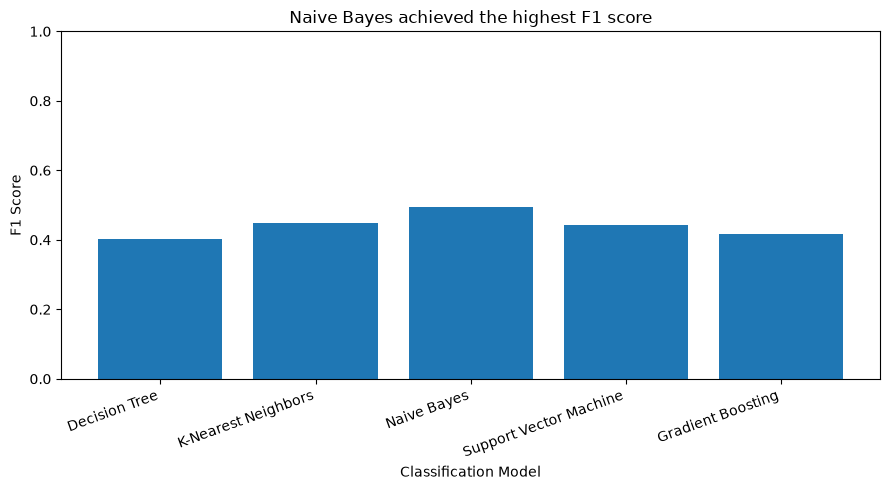

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["F1"]
)

plt.xlabel("Classification Model")
plt.ylabel("F1 Score")
plt.title(
    f"{best_model} achieved the highest F1 score"
)
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "a5_model_f1_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [40]:
# Task 14: Visualize Decision Boundaries

# Because only two features are used, every classifier's decision boundary can be drawn directly. Each panel shows how that algorithm divides the sqft_living / yr_built space into Premium and Regular regions, with the training houses plotted on top.

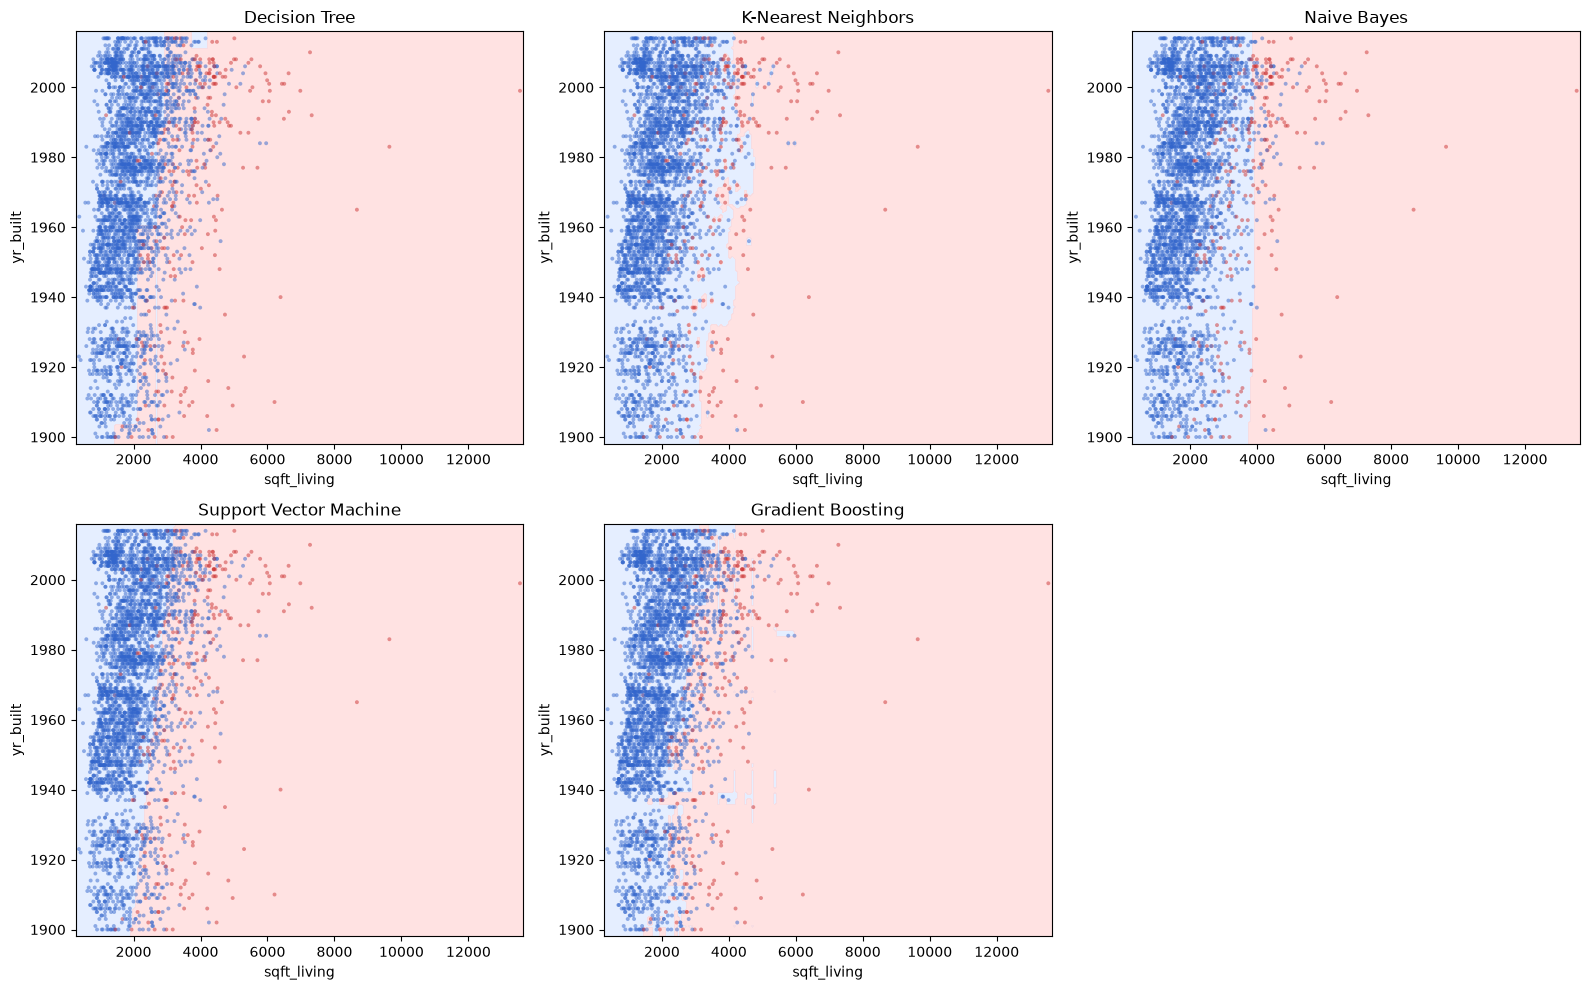

In [41]:
sqft_range = np.linspace(
    X["sqft_living"].min() - 100,
    X["sqft_living"].max() + 100,
    200
)

year_range = np.linspace(
    X["yr_built"].min() - 2,
    X["yr_built"].max() + 2,
    200
)

sqft_grid, year_grid = np.meshgrid(sqft_range, year_range)

grid_df = pd.DataFrame({
    "sqft_living": sqft_grid.ravel(),
    "yr_built": year_grid.ravel()
})

models_for_plot = {
    "Decision Tree": tree_model,
    "K-Nearest Neighbors": knn_model,
    "Naive Bayes": nb_model,
    "Support Vector Machine": svm_model,
    "Gradient Boosting": boosting_model,
}

background_cmap = ListedColormap(["#dbe7ff", "#ffd6d6"])
points_cmap = ListedColormap(["#3366cc", "#cc3333"])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (model_name, model) in zip(axes, models_for_plot.items()):
    grid_predictions = model.predict(grid_df).reshape(sqft_grid.shape)

    ax.contourf(
        sqft_grid,
        year_grid,
        grid_predictions,
        levels=[-0.5, 0.5, 1.5],
        cmap=background_cmap,
        alpha=0.7
    )

    ax.scatter(
        X_train["sqft_living"],
        X_train["yr_built"],
        c=y_train,
        cmap=points_cmap,
        s=8,
        alpha=0.5,
        edgecolors="none"
    )

    ax.set_title(model_name)
    ax.set_xlabel("sqft_living")
    ax.set_ylabel("yr_built")

axes[-1].axis("off")

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "a5_decision_boundaries.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [42]:
# Task 15: Classification Report for the Best Model

In [43]:
best_predictions = predictions_by_model[best_model]

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Regular", "Premium"]
    )
)

              precision    recall  f1-score   support

     Regular       0.95      0.98      0.97       842
     Premium       0.64      0.41      0.50        69

    accuracy                           0.94       911
   macro avg       0.79      0.69      0.73       911
weighted avg       0.93      0.94      0.93       911



In [44]:
# Task 16: Compare How Each Model Explains the Same House

# This pulls together the example house from Task 6 and shows what every classifier predicted for it, so the different reasoning styles can be compared side by side.

In [45]:
example_summary = pd.DataFrame({
    "Model": list(probabilities_by_model.keys()),
    "Predicted Probability (Premium)": [
        probabilities_by_model[model_name][EXAMPLE_INDEX]
        for model_name in probabilities_by_model
    ],
    "Predicted Class": [
        "Premium" if predictions_by_model[model_name][EXAMPLE_INDEX] == 1 else "Regular"
        for model_name in predictions_by_model
    ]
})

print("EXAMPLE HOUSE")
print("-------------")
print(example_df)
print(f"\nTrue label: {'Premium' if example_true_label == 1 else 'Regular'}\n")

example_summary.round(3)

EXAMPLE HOUSE
-------------
      sqft_living  yr_built
1807         1220      1921

True label: Regular



,Model,Predicted Probability (Premium),Predicted Class
0,Decision Tree,0.131,Regular
1,K-Nearest Neighbors,0.000,Regular
2,Naive Bayes,0.016,Regular
3,Support Vector Machine,0.013,Regular
4,Gradient Boosting,0.015,Regular


In [46]:
# Task 17: Final Conclusion

In [47]:
worst_model_row = ranked_results.iloc[-1]

conclusion = (
    f"{best_model} is the classifier I would trust most for this task. "
    f"It reached the highest F1 score ({best_f1:.3f}) among the five algorithms "
    "tested, balancing how often its premium predictions were correct "
    "(precision) against how many real premium houses it found (recall). "
    f"The weakest performer on this dataset was {worst_model_row['Model']} "
    f"(F1 = {worst_model_row['F1']:.3f})."
)

print(conclusion)

Naive Bayes is the classifier I would trust most for this task. It reached the highest F1 score (0.496) among the five algorithms tested, balancing how often its premium predictions were correct (precision) against how many real premium houses it found (recall). The weakest performer on this dataset was Decision Tree (F1 = 0.403).


In [48]:
# Task 18: Generate the One-Page Report

# This produces a single markdown file summarizing the dataset, all five algorithms and how each one makes a prediction, the comparison results, and the example house walkthrough, for use when presenting this project.

In [49]:
premium_count = int(y.sum())
regular_count = int((y == 0).sum())
premium_pct = y.mean() * 100

algorithm_summaries = {
    "Decision Tree": "Splits the data on one feature at a time using yes/no questions until it reaches a leaf that gives the prediction.",
    "K-Nearest Neighbors": "Looks at the most similar houses in the training data, by distance, and lets them vote on the prediction.",
    "Naive Bayes": "Estimates how likely each feature value is under each class and combines those likelihoods with Bayes' rule.",
    "Support Vector Machine": "Finds the line that best separates the two classes in scaled feature space and checks which side a house falls on.",
    "Gradient Boosting": "Combines many small decision trees built one after another, each correcting the errors left by the ones before it.",
}

algorithm_lines = "\n".join(
    f"- **{name}**: {summary}"
    for name, summary in algorithm_summaries.items()
)

results_table_lines = "\n".join(
    f"| {row['Model']} | {row['Accuracy']:.3f} | {row['Precision']:.3f} | "
    f"{row['Recall']:.3f} | {row['F1']:.3f} | {row['ROC_AUC']:.3f} |"
    for _, row in ranked_results.iterrows()
)

example_lines = "\n".join(
    f"- {row['Model']}: predicted {row['Predicted Class']} "
    f"(probability of Premium = {row['Predicted Probability (Premium)']:.3f})"
    for _, row in example_summary.iterrows()
)

report = f'''
# Classifier Project: Predicting Premium House Listings

## Dataset and Target

This project reuses the cleaned dataset from
`data/processed/house_prices_cleaned_featured.csv`. A house is labelled
premium when its sale price is at least ${PREMIUM_THRESHOLD:,}, using
sqft_living and yr_built as the only two predictor features. price itself
is excluded from the features because the target was derived from it.

The dataset contained {regular_count:,} regular houses and {premium_count:,}
premium houses, so premium houses represented approximately {premium_pct:.1f}%
of the data.

## Algorithms Compared

Five classifiers studied in class were trained and evaluated on the same
80/20 stratified train/test split:

{algorithm_lines}

## Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
{results_table_lines}

F1 score was used to rank the models because the premium class is rare.
A model can reach high accuracy just by predicting "regular" for almost
every house, so precision and recall, and their balance in F1, are more
informative for this problem.

## Example Walkthrough

One house from the test set was used to compare how each algorithm reasons
about the same input:

{example_lines}

True label for this house: {"Premium" if example_true_label == 1 else "Regular"}

## Conclusion

{conclusion}
'''

report_path = REPORTS_PATH / "assignment5-classifier-comparison-report.md"

report_path.write_text(
    report.strip(),
    encoding="utf-8"
)

print("Report saved to:")
print(report_path)

Report saved to:
C:\Users\Hp\Desktop\K-LAB\reports\assignment5-classifier-comparison-report.md


In [50]:
# Final Notes

# All five classifiers were trained and evaluated on exactly the same two features, the same stratified train/test split, and the same random_state, so the comparison reflects differences between the algorithms rather than differences in setup.

# K-Nearest Neighbors, Naive Bayes, and the Support Vector Machine were wrapped in a scaling Pipeline because they are sensitive to feature scale. Decision Tree and Gradient Boosting split on raw thresholds, so they do not need scaling.

# Because only sqft_living and yr_built are used, the decision boundary for every model could be drawn directly in Task 14, which is the clearest way to see how differently each algorithm partitions the same space.